In [16]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import pandas as pd
import pygmt

In [17]:
dl = pd.read_csv('..\\..\\created_data\\botlowcru.csv', sep=',', header=None, 
                 names=['long', 'lat', 'z'], skiprows=1)
print(dl.head())

dm = pd.read_csv('..\\..\\created_data\\botmidcru.csv', sep=',', header=None, 
                 names=['long', 'lat', 'z'], skiprows=1)
print(dm.head())

du = pd.read_csv('..\\..\\created_data\\botupcru.csv', sep=',', header=None, 
                 names=['long', 'lat', 'z'], skiprows=1)
print(du.head())

    long   lat      z
0 -133.0  38.0 -11.97
1 -133.0  39.0 -11.81
2 -133.0  40.0 -11.56
3 -133.0  41.0 -10.82
4 -133.0  42.0 -10.75
    long   lat     z
0 -133.0  38.0 -7.28
1 -133.0  39.0 -7.15
2 -133.0  40.0 -6.92
3 -133.0  41.0 -6.12
4 -133.0  42.0 -6.05
    long   lat     z
0 -133.0  38.0 -5.76
1 -133.0  39.0 -5.64
2 -133.0  40.0 -5.41
3 -133.0  41.0 -4.60
4 -133.0  42.0 -4.53


making a dictionary of each latitude with its corrsp long and z

*for lat in df['lat'].unique()* get all the unique lat values to loop through each one once

*blc[lat] = df[df['lat'] == lat][['long','z']]* filters the dataframe to only rows where lat equals the current lat value (38 = 38) and then keeps only long and z

In [18]:
blc = {}
for lat in dl['lat'].unique():
    blc[lat] = dl[dl['lat'] == lat][['long','z']] 

bmc= {}
for lat in dm['lat'].unique(): 
    bmc[lat] = dm[dm['lat'] == lat][['long','z']] 

buc = {}
for lat in du['lat'].unique():   
    buc[lat] = du[du['lat'] == lat][['long','z']]  

now creating a new dataframe (all) made of the long, and then each z for that long at that lat

In [19]:
all = {}
for lat in blc.keys():
    all[lat]=pd.DataFrame({  # creating a new dataframe
        'long':blc[lat]['long'].values,  # grabs the longitude values for that lat
        'z_low':blc[lat]['z'].values,  # grabbing z and so forth
        'z_mid':bmc[lat]['z'].values,
        'z_up':buc[lat]['z'].values})

In [40]:
lat = 47

In [41]:
print(all[lat])

     long      z_low      z_mid       z_up
0  -133.0 -10.740000  -6.140000  -4.650000
1  -132.0 -10.390000  -5.750000  -4.250000
2  -131.0  -9.860000  -5.200000  -3.690000
3  -130.0 -10.500000  -5.070000  -3.310000
4  -129.0 -11.860000  -5.790000  -4.230000
5  -128.0  -9.050000  -5.090000  -4.070000
6  -127.0  -9.200000  -5.340000  -4.100000
7  -126.0 -10.350000  -6.170000  -4.820000
8  -125.0 -14.640000  -7.310000  -4.950000
9  -124.0 -23.680000 -16.879999  -9.650000
10 -123.0 -28.950001 -23.049999 -12.640000
11 -122.0 -43.060001 -34.169998 -18.520000
12 -121.0 -42.669998 -33.450001 -17.200001
13 -120.0 -37.970001 -29.860001 -15.560000
14 -119.0 -36.830002 -29.049999 -15.350000


In [42]:
filt_all = all[lat][all[lat]['long'].between(-132, -127)]

In [43]:
print(filt_all)

    long  z_low  z_mid  z_up
1 -132.0 -10.39  -5.75 -4.25
2 -131.0  -9.86  -5.20 -3.69
3 -130.0 -10.50  -5.07 -3.31
4 -129.0 -11.86  -5.79 -4.23
5 -128.0  -9.05  -5.09 -4.07
6 -127.0  -9.20  -5.34 -4.10


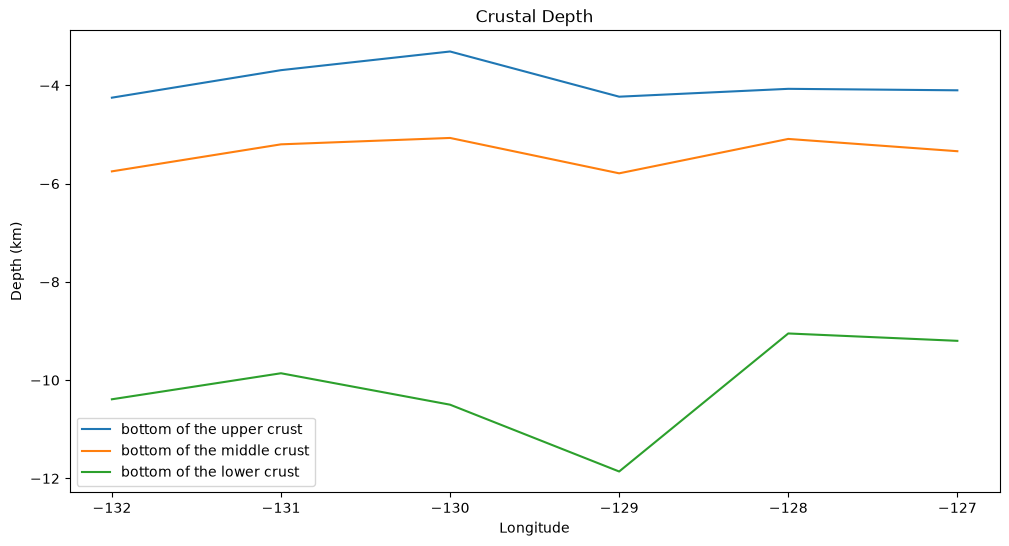

In [47]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(filt_all['long'], filt_all['z_up'], label='bottom of the upper crust')
ax.plot(filt_all['long'], filt_all['z_mid'], label='bottom of the middle crust')
ax.plot(filt_all['long'], filt_all['z_low'], label='bottom of the lower crust')

ax.set_xlabel('Longitude')
ax.set_ylabel('Depth (km)')
ax.set_title('Crustal Depth')
ax.legend()
plt.show()